C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\1829440795.py:213: RuntimeWarning:

Mean of empty slice

C:\Users\manur\AppData\Local\Temp\ipy

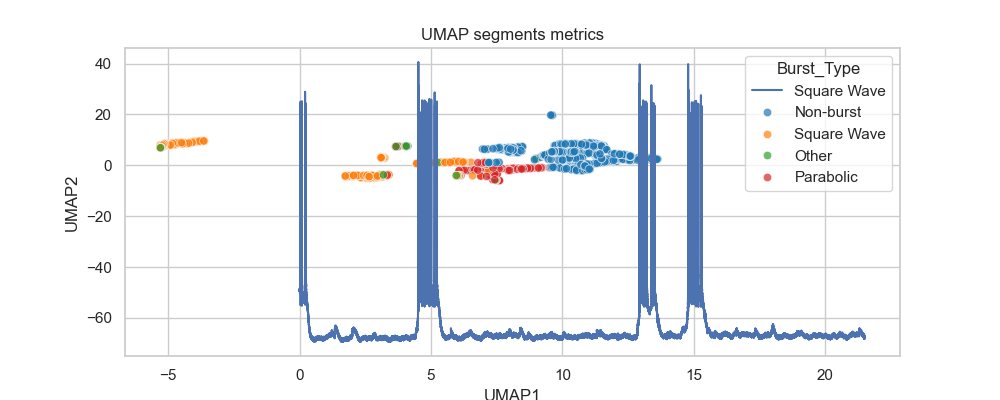

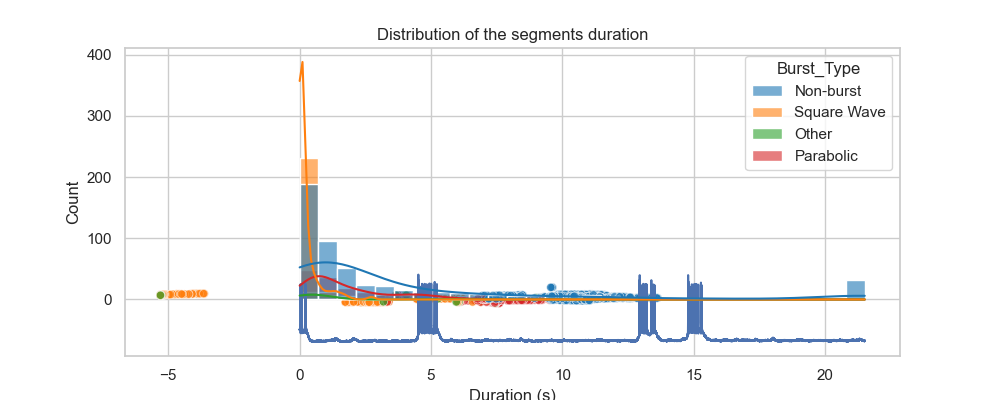

In [8]:

# 1) Standard imports

import os
# Standard library: for listing files and building platform-independent paths.

import pyabf
# pyabf is a small library that reads .abf (Axon Binary Format) electrophysiology files.
# It exposes sweepCount, dataRate, sweepX (time per sweep) and sweepY (voltage per sweep).

import numpy as np
# NumPy is the backbone for numerical operations on arrays. Use vectorized ops to keep code fast.

import pandas as pd
# pandas is used to collect results as a DataFrame and to write CSVs for downstream analysis.

from scipy.stats import skew, kurtosis
# Higher-order statistics: third (skew) and fourth (kurtosis) moments can capture waveform asymmetry and tail heaviness.

from scipy.signal import find_peaks, hilbert
# find_peaks: convenient and flexible peak detector (many useful parameters).
# hilbert: analytic signal transform used to compute envelope and instantaneous phase.
# The Hilbert transform assumes reasonably band-limited signals, be cautious with noise.

from numpy.linalg import lstsq
# Least-squares solver used to fit a quadratic (parabola) to burst shapes.
# Useful to quantify how well a burst follows a parabola (R^2).

from sklearn.metrics import r2_score
# R^2 (coefficient of determination) quantifies goodness-of-fit of the parabola.

# In interactive Jupyter contexts we want widget-based plotting
%matplotlib widget


# 2) ML & visualization imports
import umap
# UMAP is a nonlinear dimensionality reduction technique that preserves local structure.
# It is useful for visualization of high-dimensional features (be mindful of hyperparameters).

from sklearn.preprocessing import StandardScaler
# StandardScaler rescales features to zero mean and unit variance, normally required prior to UMAP or many ML methods.

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Force Plotly to open in the system browser (works well when notebook inline rendering behaves oddly)
pio.renderers.default = "browser"


# 3) Analysis parameters (tune these for your data)

folder_path = "bursting"   # Directory containing .abf files to analyze.
# Make sure this path is correct and contains .abf files, else the script will find none.

threshold = -35            # Peak detection threshold in mV.
# Assumption: spikes are positive-going peaks above -35 mV.
# If your data are inverted, invert signal before calling find_peaks or set threshold accordingly.

burst_threshold = 0.3      # ISI threshold (seconds) to consider consecutive spikes part of same burst.


fs = 10000                 # Sampling frequency in Hz (used to convert indices, times).

dt = 1 / fs                # Time step in seconds. Used for derivative and area computations.

# Burst definition criteria, tune to your recording and cell type.
min_spikes_in_burst = 4    # Minimum number of spikes required to consider a cluster a burst.
# Using 4 prevents counting small pairs/triplets, but if your bursts are shorter, lower this.

max_isi = 0.3              # Maximum ISI allowed inside burst (same meaning as burst_threshold here).
min_spike_rate = 5         # Minimum average spike rate (Hz) inside a burst to qualify (used optionally).

# Container to accumulate per-segment metrics across all files and sweeps
all_segment_metrics = []



# 4) Collect ABF files from folder

# We only look at top-level files in folder_path with ".abf" extension.
# If you want to traverse subdirectories use os.walk or pathlib.rglob.
abf_files = [f for f in os.listdir(folder_path) if f.endswith(".abf")]

# Safety check: helpful to early-fail if folder is wrong or empty.
if len(abf_files) == 0:
    # Raise informative error — you can comment this out if you prefer to silently continue.
    raise FileNotFoundError(f"No .abf files found in folder '{folder_path}'. Check path.")


# 5) Main processing loop over files and sweeps

for file_name in abf_files:
    # Build cross-platform path and load the ABF file.
    file_path = os.path.join(folder_path, file_name)
    abf = pyabf.ABF(file_path)  # pyabf handles file parsing, this object exposes sweepCount, dataRate, etc.

    # Iterate over sweeps (trials) within the ABF file
    for sweep in range(abf.sweepCount):
        # Set the current sweep so pyabf provides sweepX and sweepY for that sweep
        abf.setSweep(sweep)

        # Per-sweep time and voltage vectors.
        time = abf.sweepX
        voltage = abf.sweepY

        # If you want to use file-specific sampling rate, use:
        # fs_file = abf.dataRate
        # dt = 1.0 / fs_file
        # and replace uses of global fs/dt above accordingly.


        # 5.1 Spike detection

        # find_peaks returns indices of local maxima that satisfy a min height constraint.
        # It also supports 'prominence', 'distance', and other guards to reduce false positives.
        peaks, _ = find_peaks(voltage, height=threshold)

        # Convert indices to times in seconds. If fs differs per-file, use abf.dataRate instead.
        spike_times = peaks / fs

        # Edge cases:
        # - no peaks detected: spike_times will be empty, downstream code must handle length 0 gracefully.
        # - occasional noise may create false peaks, consider adding prominence or smoothing.


        # 5.2 Burst detection (cluster spikes by ISI)

        bursts = []  # will hold tuples (burst_start_time, burst_end_time)

        # Only attempt detection when enough spikes exist to possibly form a burst
        if len(spike_times) >= min_spikes_in_burst:
            isi = np.diff(spike_times)     # inter-spike intervals (seconds)
            current_burst = [spike_times[0]]

            # Walk through spikes, group them when ISI < burst_threshold
            for i in range(1, len(spike_times)):
                if isi[i-1] < burst_threshold:
                    # short gap: same burst
                    current_burst.append(spike_times[i])
                else:
                    # long gap: close and save the burst if it meets min_spikes_in_burst
                    if len(current_burst) >= min_spikes_in_burst:
                        bursts.append((current_burst[0], current_burst[-1]))
                    # start new burst accumulator
                    current_burst = [spike_times[i]]

            # after the loop, save the last accumulated burst if valid
            if len(current_burst) >= min_spikes_in_burst:
                bursts.append((current_burst[0], current_burst[-1]))
        # At this point bursts is a list of (start, end) times for each detected burst.


        # 5.3 Build chronological segments: bursts and non-bursts
        segments = []  # list of (start, end, "Burst" or "Non-burst")

        # Add detected burst intervals first
        for start, end in bursts:
            segments.append((start, end, "Burst"))

        if bursts:
            # If bursts exist, also add non-burst sections before first, between bursts, and after last
            # Pre-burst segment (only if there is time before first burst)
            if bursts[0][0] > time[0]:
                segments.insert(0, (time[0], bursts[0][0], "Non-burst"))

            # Non-burst intervals between consecutive bursts
            for i in range(len(bursts) - 1):
                segments.append((bursts[i][1], bursts[i+1][0], "Non-burst"))

            # Post-burst segment (only if recording continues after last burst)
            if bursts[-1][1] < time[-1]:
                segments.append((bursts[-1][1], time[-1], "Non-burst"))
        else:
            # If no bursts were detected, the entire sweep is a single "Non-burst" segment
            segments.append((time[0], time[-1], "Non-burst"))


        # 5.4 Classify bursts by waveform shape

        # We'll derive a burst type for each segment (only bursts are classified).
        burst_types = []

        # Iterate segments in chronological order and classify only those with seg_type == "Burst"
        for i, (seg_start, seg_end, seg_type) in enumerate(segments):
            if seg_type == "Burst":
                # Extract signal belonging to this burst window
                seg_mask = (time >= seg_start) & (time <= seg_end)
                seg_voltage = voltage[seg_mask]
                seg_time = time[seg_mask]

                # Compute local baseline as average of pre- and post-burst means
                # This baseline lets us decide whether the burst minima is above or below ambient level.
                prev_mean = np.nan
                next_mean = np.nan

                # Mean between previous segment's end and this burst start (if previous segment exists)
                if i > 0:
                    prev_end = segments[i - 1][1]
                    inter_mask_prev = (time > prev_end) & (time < seg_start)
                    if np.any(inter_mask_prev):
                        prev_mean = np.mean(voltage[inter_mask_prev])

                # Mean between this burst end and next segment's start (if next segment exists)
                if i < len(segments) - 1:
                    next_start = segments[i + 1][0]
                    inter_mask_next = (time > seg_end) & (time < next_start)
                    if np.any(inter_mask_next):
                        next_mean = np.mean(voltage[inter_mask_next])

                # Combine pre/post means to get a robust local baseline (NaNs ignored)
                inter_mean = np.nanmean([prev_mean, next_mean])


                # Burst minimum
                burst_min = np.min(seg_voltage)

                # Parabolic fit: is the burst shape well approximated by a quadratic curve?
                # Fit y = a t^2 + b t + c over a normalized time vector t in [-0.5, 0.5].
                # Using least squares provides coefficients that we can use to compute predicted y_hat.
                # R^2 quantifies how much variance the parabola explains in the burst waveform.
                t = np.linspace(-0.5, 0.5, len(seg_voltage))
                # Design matrix for quadratic [t^2, t, 1]
                X = np.vstack([t**2, t, np.ones_like(t)]).T
                # Solve least squares (coef = [a, b, c])
                coef, *_ = lstsq(X, seg_voltage, rcond=None)
                y_hat = X @ coef
                # R^2: 1 - SS_res / SS_tot
                r2_parabola = r2_score(seg_voltage, y_hat)
                # Interpretation: r2 close to 1, burst very parabola-like, close to 0, poor fit.

                # Envelope symmetry using Hilbert transform 
                # Compute analytic signal, take absolute value, envelope. Compare first half to reversed second half.
                analytic_signal = hilbert(seg_voltage)
                envelope = np.abs(analytic_signal)
                half = len(envelope) // 2
                # If burst is too short, symmetry measure is unstable, return NaN.
                symmetry = (np.corrcoef(envelope[:half], envelope[-half:][::-1])[0, 1]
                            if half >= 2 else np.nan)
                # symmetry close to +1, envelope is symmetric, close to 0 or negative, asymmetric.

                # Spike metrics inside burst: number & rate
                seg_peaks, _ = find_peaks(seg_voltage, height=threshold)
                # spike_rate in Hz: number of spikes divided by burst duration
                spike_rate = len(seg_peaks) / (seg_end - seg_start) if (seg_end - seg_start) > 0 else np.nan

                # Decide burst type
                # Rules:
                #  - if inter_mean is NaN (no surrounding baseline), classification is ambiguous, "Other"
                #  - if burst_min > inter_mean, burst sits above baseline, "Square Wave"
                #  - if burst_min < inter_mean, burst dips below baseline, "Parabolic"

                if np.isnan(inter_mean):
                    burst_type = "Other"
                elif burst_min > inter_mean:
                    burst_type = "Square Wave"
                elif burst_min < inter_mean:
                    burst_type = "Parabolic"
                else:
                    burst_type = "Other"

            else:
                # Non-burst segments are labeled explicitly
                burst_type = "Non-burst"

            burst_types.append(burst_type)


        # 5.5 Compute and store segment-level metrics

        # For each chronological segment (burst or non-burst) compute a set of features
        # that will be saved to CSV and later used for UMAP / downstream analysis.

        for j, (seg_start, seg_end, seg_type) in enumerate(segments):
            # Create mask and extract segment voltage
            seg_mask = (time >= seg_start) & (time <= seg_end)
            seg_voltage = voltage[seg_mask]

            # Duration of segment in seconds
            duration = seg_end - seg_start

            # The burst type previously computed (parallel list)
            burst_type = burst_types[j]

            # Spike-based features inside the segment
            seg_peaks, _ = find_peaks(seg_voltage, height=threshold)
            num_peaks = len(seg_peaks)
            # mean ISI in seconds (if at least two peaks exist), converting indices, time via fs
            mean_isi = np.mean(np.diff(seg_peaks / fs)) if num_peaks >= 2 else 0

            # Basic voltage statistics
            # Guard: small segments (<2 samples) cannot provide stats, return zeros to keep table consistent.
            if len(seg_voltage) < 2:
                mean_val = std_val = min_val = max_val = skew_val = kurt_val = area_val = 0
            else:
                mean_val = np.mean(seg_voltage)
                std_val = np.std(seg_voltage)
                min_val = np.min(seg_voltage)
                max_val = np.max(seg_voltage)
                # Skewness and kurtosis measure distribution shape (sensitive to outliers)
                skew_val = skew(seg_voltage)
                kurt_val = kurtosis(seg_voltage)
                # Area under the curve (approx integral) using trapezoidal rule
                # We use a fixed dx=dt (assumes regular sampling). If using abf.sweepX, use np.trapz(seg_voltage, seg_time)
                area_val = np.trapezoid(seg_voltage, dx=dt)

            # Derivative (slope) statistics
            # The derivative highlights rapid changes (spike upstrokes, downstrokes).
            if len(seg_voltage) < 2:
                mean_d = std_d = min_d = max_d = skew_d = kurt_d = 0
            else:
                deriv = np.diff(seg_voltage) / dt  # units: mV/s
                mean_d = np.mean(deriv)
                std_d = np.std(deriv)
                min_d = np.min(deriv)
                max_d = np.max(deriv)
                skew_d = skew(deriv)
                kurt_d = kurtosis(deriv)

            # Persist features as a row to the global metrics list
            # We keep a fixed order of columns so it's easy to create a DataFrame later.
            all_segment_metrics.append([
                file_name, sweep, seg_type, burst_type, duration,
                num_peaks, mean_isi,
                mean_val, std_val, min_val, max_val, skew_val, kurt_val, area_val,
                mean_d, std_d, min_d, max_d, skew_d, kurt_d
            ])



# 6) Save results to CSV

# Convert the accumulated list into a pandas DataFrame with explicit column names.
df_segments = pd.DataFrame(all_segment_metrics, columns=[
    "File_Name", "Sweep", "Segment_Type", "Burst_Type", "Duration",
    "Num_Peaks", "Mean_ISI",
    "Mean", "Std", "Min", "Max", "Skewness", "Kurtosis", "Area",
    "Mean_Deriv", "Std_Deriv", "Min_Deriv", "Max_Deriv", "Skewness_Deriv", "Kurtosis_Deriv"
])

# Write the DataFrame out to CSV for reproducibility and downstream analysis.
out_csv = "segment_voltage_metrics_with_ISI_and_peaks.csv"
df_segments.to_csv(out_csv, index=False)
# Note: index=False prevents adding the DataFrame row index as an extra column.



# 7) Visualization (UMAP & distributions)

# The rest of the script loads the CSV (to ensure reproducibility of saved results)
# and then performs dimensionality reduction (UMAP) followed by static & interactive plotting.

sns.set(style='white', context='notebook', rc={'figure.figsize': (14, 10)})

# Re-load the CSV to simulate a fresh analysis environment (optional, you could reuse df_segments directly)
df = pd.read_csv(out_csv)

# Choose feature columns for UMAP:
# We intentionally skip the first four metadata columns (File_Name, Sweep, Segment_Type, Burst_Type)
header = list(df)[4:]  # all column names starting from "Duration"
X = np.array(df[header])  # feature matrix (n_samples x n_features)
y = np.array(df.Burst_Type)  # labels for coloring in plots

# Feature scaling
# Many features are on different numeric scales (duration in seconds, area in mV*s, skewness unitless).
# Standardize to zero mean & unit variance so UMAP's distance metric treats them comparably.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP embedding (2D)
# UMAP hyperparameters (n_neighbors, min_dist) influence global vs local structure, defaults are usually ok for visualization.
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)  # result: array (n_samples, 2)

# Create a succinct DataFrame for plotting
df_umap = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
df_umap["Burst_Type"] = y

# Static UMAP scatterplot (seaborn)
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2",
                hue="Burst_Type", palette="tab10", alpha=0.7)
plt.title("UMAP segments metrics")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

# Distribution of segment durations (histogram)
sns.set(style="whitegrid", context="notebook", rc={'figure.figsize': (10, 6)})
sns.histplot(data=df_segments, x="Duration", hue="Burst_Type",
             bins=30, kde=True, palette="tab10", alpha=0.6)
plt.title("Distribution of the segments duration")
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.show()

# Interactive UMAP (Plotly)
# Useful for zooming and hovering to inspect individual points (e.g., show file/sweep info if added).
fig = px.scatter(df_umap, x="UMAP1", y="UMAP2", color="Burst_Type", title="UMAP")
pio.renderers.default = "browser"
fig.show()




Distance between centroids of burst types:
Burst_Type   Non-burst     Other  Parabolic  Square Wave
Burst_Type                                              
Non-burst     0.000000  6.982493   6.356981     9.964681
Other         6.982493  0.000000   5.053357     2.984769
Parabolic     6.356981  5.053357   0.000000     7.086916
Square Wave   9.964681  2.984769   7.086916     0.000000

Overlap threshold (UMAP distance): 3.192

Potentially overlapping burst type pairs:
[('Other', 'Square Wave')]

Number of segments in conflict regions: 147
Burst_Type
Non-burst      17
Other          21
Parabolic      73
Square Wave    36
dtype: int64


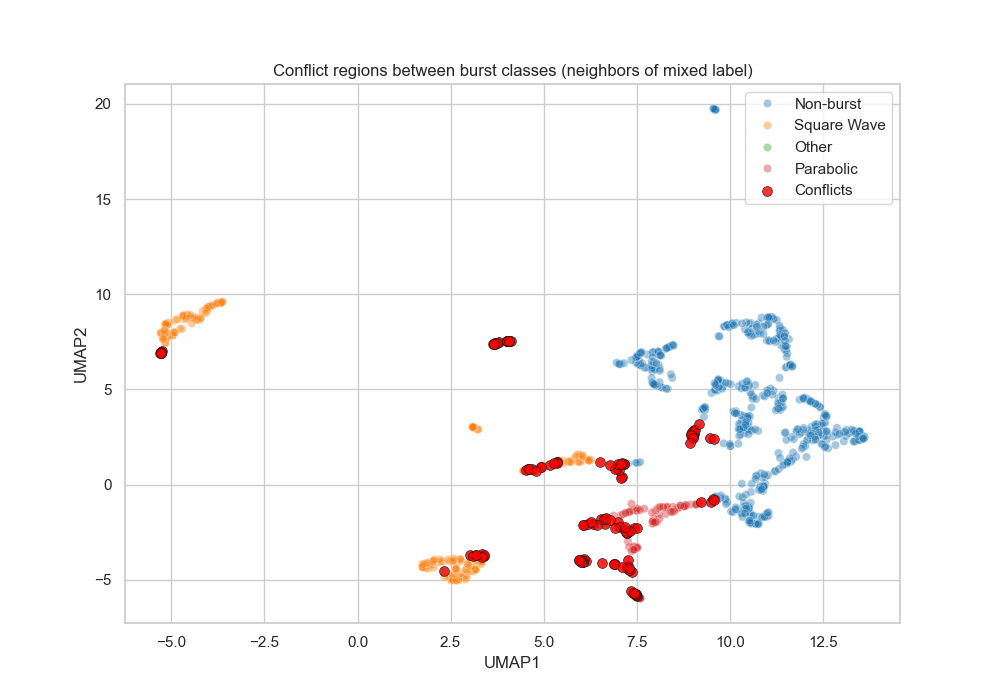

In [9]:

# Conflict-region detection on UMAP embedding

# Purpose:
# - Compute cluster centroids in UMAP space for each burst type
# - Measure centroid-to-centroid distances and detect potentially overlapping classes
# - Use nearest-neighbors to find individual points that lie in mixed/conflict neighborhoods
# - Plot the embedding highlighting those conflict points
#
# Assumptions:
# - df_umap is a DataFrame with columns ["UMAP1","UMAP2","Burst_Type"]
# - df_segments is a DataFrame containing the original per-segment features, in the same row order as df (used earlier)
# - Both DataFrames have consistent indexing (df_umap was built from df, so df_umap.Index maps back to df indices)


from scipy.spatial import distance            # For pairwise distance computations (cdist)
from sklearn.neighbors import NearestNeighbors  # For efficient k-NN queries
%matplotlib widget                              


# STEP 0, make sure we can trace back to original rows

# Add an "Index" column to df_umap storing the row index of the original df (or df_segments).
# This allows us to map points flagged in UMAP space back to the original dataset (for inspection).
df_umap["Index"] = df.index   # df is the full features DataFrame used to create df_umap

# Note:
# - We assume df.index contains the proper integer row positions corresponding to df_segments.
# - If df was reindexed, ensure df_umap["Index"] was created from the same df used earlier.


# 1) Compute centroids per class in UMAP space

# Compute the mean UMAP coordinates for each Burst_Type label. This yields one (UMAP1,UMAP2)
# point per class, the centroid (geometric center) in embedding space.
centroids = df_umap.groupby("Burst_Type")[["UMAP1", "UMAP2"]].mean()


# 2) Distance matrix between centroids

# Compute pairwise Euclidean distances between the centroids. distance.cdist yields a
# square matrix where entry (i,j) is dist(centroid_i, centroid_j).
dist_matrix = distance.cdist(centroids.values, centroids.values)

# Put distances into a DataFrame for pretty printing and indexing by class labels
dist_df = pd.DataFrame(dist_matrix, index=centroids.index, columns=centroids.index)

print("\nDistance between centroids of burst types:")
print(dist_df)   # Show numeric distances, diagonal will be zero (distance to self)


# 2a) Decide an "overlap" threshold

# Heuristic: define overlap threshold as the 10th percentile of non-zero centroid distances.
# Rationale: if two centroids are unusually close compared to the typical centroid separation,
# they might represent overlapping or poorly-separated classes in UMAP space.
threshold = np.percentile(dist_matrix[dist_matrix > 0], 10)  # 10th percentile of positive distances
print(f"\nOverlap threshold (UMAP distance): {threshold:.3f}")


# 2b) Find centroid pairs closer than threshold

close_pairs = []
# Loop over centroid pairs (upper triangle) and collect those with distance < threshold
for i, type_i in enumerate(centroids.index):
    for j, type_j in enumerate(centroids.index):
        if j > i and dist_matrix[i, j] < threshold:
            close_pairs.append((type_i, type_j))

print("\nPotentially overlapping burst type pairs:")
print(close_pairs)   # List of tuples (typeA, typeB) whose centroids are very close


# 3) Identify individual points in mixed/conflict neighborhoods

# Prepare arrays: UMAP coordinates and corresponding class labels
X_umap = df_umap[["UMAP1", "UMAP2"]].values
labels = df_umap["Burst_Type"].values

# Build a nearest-neighbors model.
# Choose k (n_neighbors) large enough to capture local neighborhood structure but not so large
# that we average across distant clusters. Here k = 8 is used as in your original code.
nbrs = NearestNeighbors(n_neighbors=8).fit(X_umap)

# Query the model to get the distances and neighbor indices for each point
distances, indices = nbrs.kneighbors(X_umap)
# - distances[i] is an array of distances from point i to its k neighbors
# - indices[i] contains row indices (into X_umap) of these neighbors

# Now identify points whose neighborhood contains at least one different class label.
conflict_indices = []  # will hold original df indices for conflict points

# Iterate through each point and its neighbors
for i, neighbors in enumerate(indices):
    own_type = labels[i]                  # label of the current point
    neighbor_types = labels[neighbors]    # labels of its k neighbors
    # If any neighbor has a different type, mark this point as in a conflict/mixed region
    if np.any(neighbor_types != own_type):
        # Append the original DataFrame index (we stored it in df_umap["Index"])
        conflict_indices.append(df_umap.iloc[i]["Index"])

# Map the conflict_indices (which point to df indices) into the original segments DataFrame
# This gives full metadata for those rows (file name, sweep, burst type, etc.).
conflicts_df = df_segments.iloc[conflict_indices]

print(f"\nNumber of segments in conflict regions: {len(conflicts_df)}")
print(conflicts_df.groupby("Burst_Type").size())   # Show how many conflict points per class


# 4) Visualize conflict points on UMAP embedding

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

# Plot all points colored by Burst_Type with some transparency so overlaps are visible
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2",
                hue="Burst_Type", alpha=0.4, palette="tab10")

# Overlay the conflict points in solid red to make them stand out
# Here we index df_umap by the positions corresponding to conflict_indices.

# We therefore locate rows in df_umap whose "Index" column matches our conflict set.
conflict_mask = df_umap["Index"].isin(conflict_indices)
sns.scatterplot(data=df_umap[conflict_mask], x="UMAP1", y="UMAP2",
                color="red", s=50, label="Conflicts", alpha=0.8, edgecolor="k")

plt.legend()
plt.title("Conflict regions between burst classes (neighbors of mixed label)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

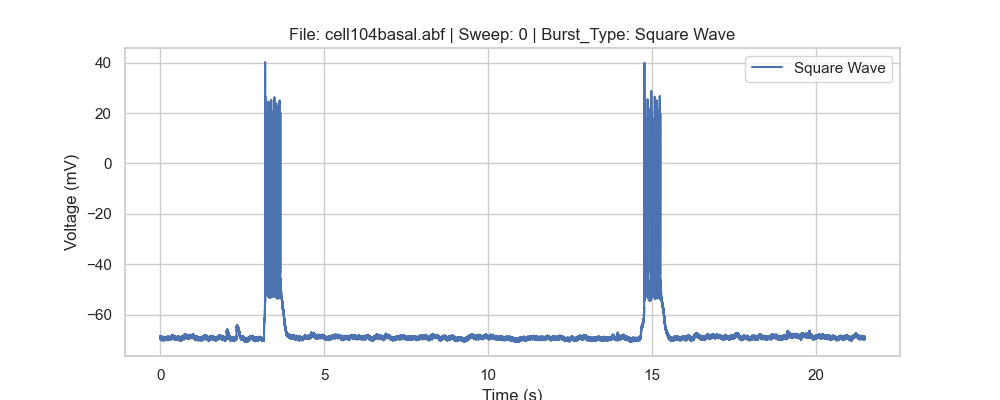

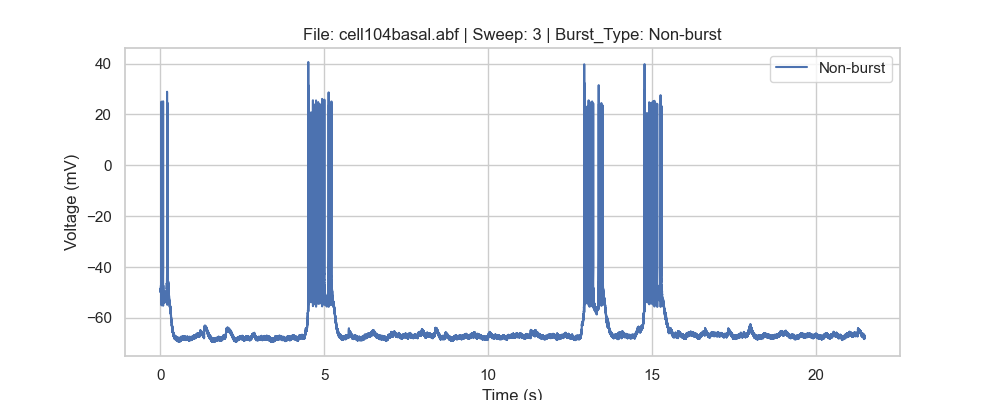

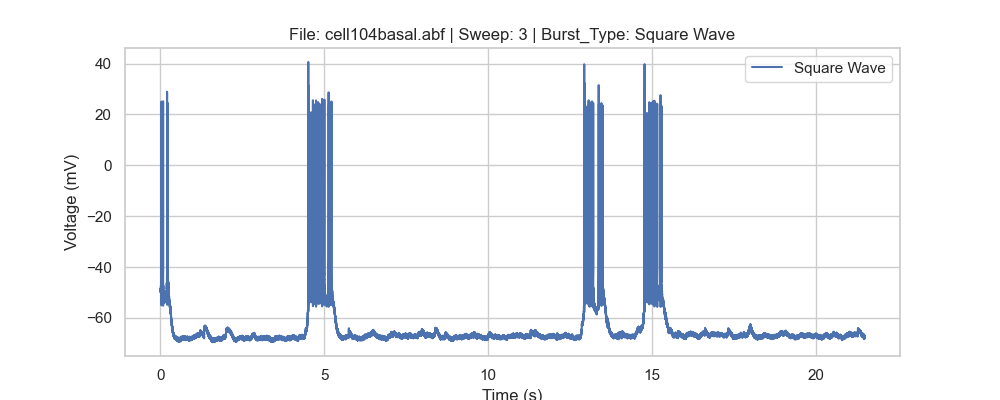

In [10]:
# Inspect and visualize example conflicting segments

# Loop over the first three conflicting segments (rows) in the conflicts_df DataFrame.
# Each row corresponds to one segment (from df_segments) that was flagged as a conflict.
for idx in conflicts_df.head(3).index:  
    # "head(3)" limits to the first three conflicts for manual inspection.
    # "index" provides the actual DataFrame indices to iterate over.

    # Extract the full row for this conflict segment.
    row = conflicts_df.loc[idx]             
    # The row contains metadata: File_Name, Sweep, Burst_Type, etc.
    # We'll use it to locate and load the corresponding sweep from the ABF file.

    # Construct the full path to the ABF file by joining the folder path and filename.
    file_path = os.path.join(folder_path, row["File_Name"])
 

    # Load the ABF (Axon Binary Format) electrophysiological recording.
    abf = pyabf.ABF(file_path)
    # pyabf reads native Axon Instruments recordings and exposes sweeps
    # (time-voltage pairs) for analysis and plotting.

    # Set the sweep number that corresponds to the segment of interest.
    # Each ABF file can contain multiple sweeps (trials). We select the one
    # where this specific segment (conflict) was detected.
    abf.setSweep(row["Sweep"])

    # Retrieve the time and voltage arrays for the current sweep.
    time = abf.sweepX       # Time vector in seconds
    voltage = abf.sweepY    # Voltage signal in millivolts

 
    # Visualization of the full sweep (or potentially zoomed region)

    # Define a boolean mask selecting the portion of time to plot.
    # Here, we simply plot the entire sweep (from start to end).
    # However, you could refine this mask to only show the specific
    # segment boundaries (e.g., using seg_start and seg_end).
    mask = (time >= 0) & (time <= time[-1])

    # Create a figure for the sweep plot.
    plt.figure(figsize=(10, 4))  # width=10 inches, height=4 inches

    # Plot voltage versus time for the masked region.
    plt.plot(time[mask], voltage[mask], label=f"{row['Burst_Type']}")

    # Add a descriptive title with the file name, sweep number, and burst type.
    plt.title(f"File: {row['File_Name']} | Sweep: {row['Sweep']} | Burst_Type: {row['Burst_Type']}")

    # Label the axes for clarity.
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")

    # Add a legend identifying the burst type (helps when comparing multiple traces).
    plt.legend()

    # Display the plot interactively (since %matplotlib widget is active).
    plt.show()




Potentially overlapping burst type pairs (by centroids):
[('Other', 'Square Wave')]

Number of segments in conflict regions: 147
Burst_Type
Non-burst      17
Other          21
Parabolic      73
Square Wave    36
dtype: int64


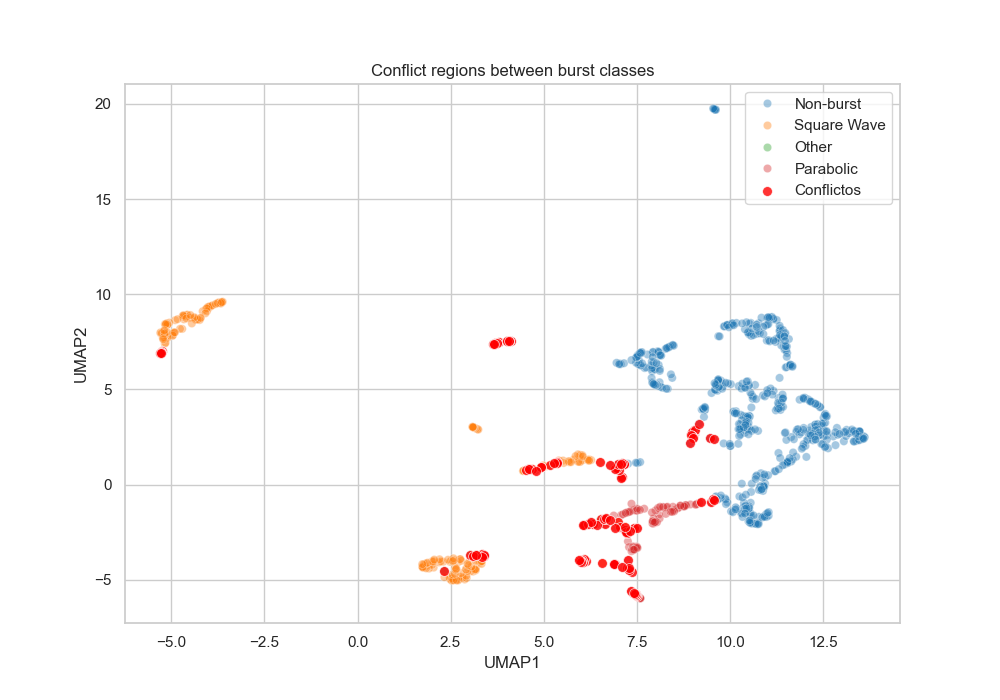

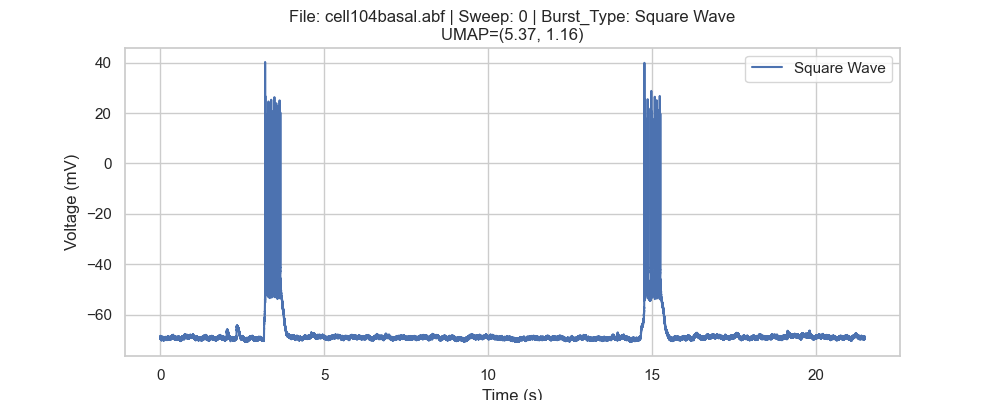

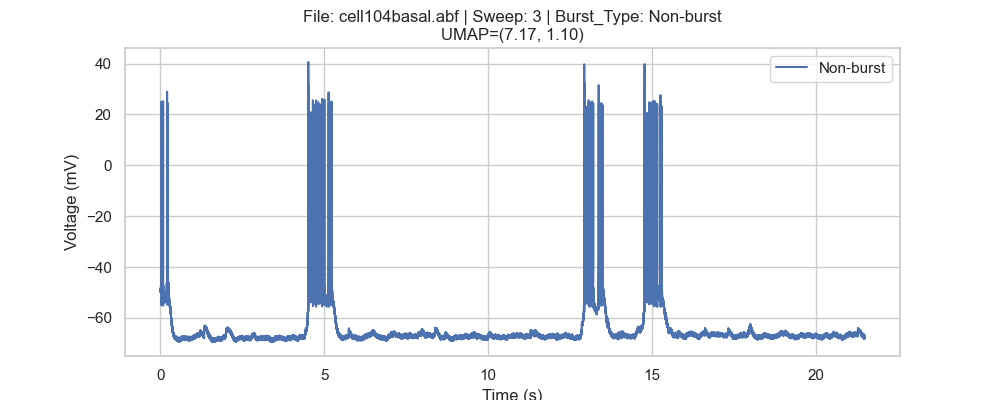

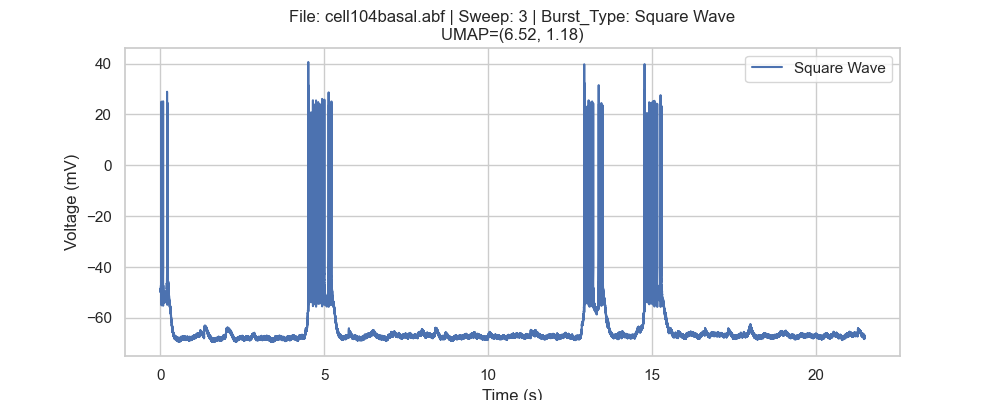


File 'conflict_segments_with_umap.csv' saved with metrics and UMAP coordinates of conflict points.


In [11]:

# UMAP Conflict Detection & Visualization for Burst Type Overlap
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors


# 1. Link UMAP data with original dataset

df_umap["Index"] = df.index  


# 2. Compute centroids and detect overlapping classes

# Compute the mean UMAP1 and UMAP2 coordinates for each burst type.
# These serve as the cluster centroids (representative locations).
centroids = df_umap.groupby("Burst_Type")[["UMAP1", "UMAP2"]].mean()

# Compute the full pairwise distance matrix between all centroids.
# This gives a symmetric matrix of Euclidean distances in UMAP space.
dist_matrix = distance.cdist(centroids.values, centroids.values)

# Define a distance threshold for considering classes as "close" or "overlapping."
# Here, the threshold is set to the 10th percentile of all nonzero centroid distances.
# This means the closest 10% of centroid pairs will be flagged as potentially overlapping.
threshold = np.percentile(dist_matrix[dist_matrix > 0], 10)

# Find all pairs of burst types whose centroids are separated by less than the threshold.
# These pairs are likely to correspond to overlapping or poorly separated classes.
close_pairs = []
for i, type_i in enumerate(centroids.index):
    for j, type_j in enumerate(centroids.index):
        if j > i and dist_matrix[i, j] < threshold:
            close_pairs.append((type_i, type_j))

print("\nPotentially overlapping burst type pairs (by centroids):")
print(close_pairs)


# 3. Detect individual points that lie in mixed regions
# Extract UMAP coordinates and class labels for all points.
X_umap = df_umap[["UMAP1", "UMAP2"]].values
labels = df_umap["Burst_Type"].values

# Build a k-nearest-neighbor model in UMAP space.
# Each point will be compared with its 8 nearest neighbors.
# The idea: if a point's neighbors belong to multiple burst types,
# that point lies near a class boundary or an overlapping region.
nbrs = NearestNeighbors(n_neighbors=8).fit(X_umap)
distances, indices = nbrs.kneighbors(X_umap)

# Initialize a list to store indices of "conflict" points.
conflict_indices = []

# Loop through each point and check its neighbors.
for i, neighbors in enumerate(indices):
    own_type = labels[i]
    neighbor_types = labels[neighbors]
    # If at least one neighbor belongs to a different class, conflict
    if np.any(neighbor_types != own_type):
        conflict_indices.append(df_umap.iloc[i]["Index"])


# 4. Extract metadata and coordinates for conflict points
# Retrieve full metadata for conflict segments from df_segments
conflicts_df = df_segments.iloc[conflict_indices]

# Retrieve their UMAP coordinates for visualization.
conflict_umap_coords = df_umap.iloc[conflict_indices][["UMAP1", "UMAP2", "Burst_Type"]]

# Some columns overlap between these two DataFrames.
# Drop duplicates before joining them to avoid merge conflicts.
conflict_umap_coords_nodup = conflict_umap_coords.drop(columns=["Burst_Type"])

# Merge metrics and UMAP coordinates into one DataFrame for convenience.
conflict_data = conflicts_df.copy()
conflict_data = conflict_data.join(conflict_umap_coords_nodup.set_index(conflict_data.index))

# Print summary of detected conflicts.
print(f"\nNumber of segments in conflict regions: {len(conflict_data)}")
print(conflict_data.groupby("Burst_Type").size())


# 5. Visualize UMAP embedding with conflict points highlighted
plt.figure(figsize=(10, 7))

# Scatter plot of all UMAP points, colored by burst type.
# Alpha transparency allows overlapping regions to be visually identified.
sns.scatterplot(
    data=df_umap, x="UMAP1", y="UMAP2",
    hue="Burst_Type", alpha=0.4, palette="tab10"
)

# Overlay conflict points in red to show where class boundaries blur.
sns.scatterplot(
    data=conflict_umap_coords,
    x="UMAP1", y="UMAP2",
    color="red", s=50, label="Conflictos", alpha=0.8
)

plt.legend()
plt.title("Conflict regions between burst classes")
plt.show()

# 6. Inspect raw voltage traces for example conflict segments
# Define how many example conflict sweeps to visualize.
N = 3  

# Loop through the first N conflicts to visually inspect their signals.
for idx in conflict_data.head(N).index:
    row = conflict_data.loc[idx]

    # Load the original ABF file corresponding to this conflict.
    file_path = os.path.join(folder_path, row["File_Name"])
    abf = pyabf.ABF(file_path)
    abf.setSweep(row["Sweep"])

    # Extract the full sweep time and voltage data.
    time = abf.sweepX
    voltage = abf.sweepY

    # Define segment range to plot (currently the entire sweep).
    # This could be refined to focus only on the specific segment range.
    seg_start = time.min()
    seg_end = time.max()
    mask = (time >= seg_start) & (time <= seg_end)

    # Plot the voltage trace for this sweep.
    plt.figure(figsize=(10, 4))
    plt.plot(time[mask], voltage[mask], label=f"{row['Burst_Type']}")
    plt.title(
        f"File: {row['File_Name']} | Sweep: {row['Sweep']} | Burst_Type: {row['Burst_Type']}\n"
        f"UMAP=({row['UMAP1']:.2f}, {row['UMAP2']:.2f})"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.legend()
    plt.show()


# 7. Save results for reproducibility and further analysis

# Export the conflict dataset (with UMAP coordinates) to a CSV file.
# This allows further inspection, manual labeling, or batch plotting later.
conflict_data.to_csv("conflict_segments_with_umap.csv", index=False)

print("\nFile 'conflict_segments_with_umap.csv' saved with metrics and UMAP coordinates of conflict points.")

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\3284055771.py:117: RuntimeWarning:

Mean of empty slice

c:\Users\manur\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



CSV saved with 951 segments and UMAP coordinates.
158 segments are in conflict regions.
231 conflict pairs detected.


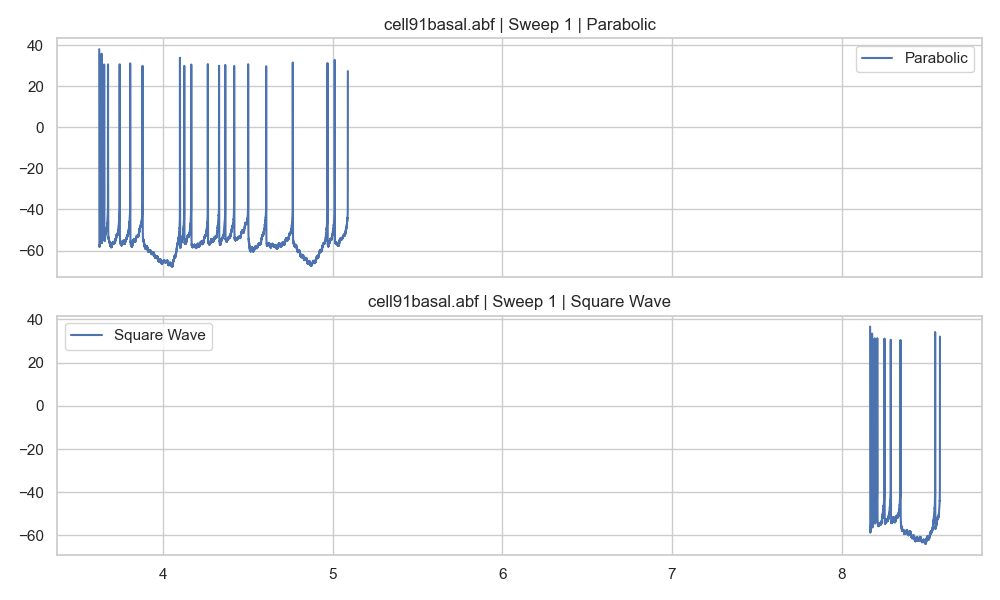

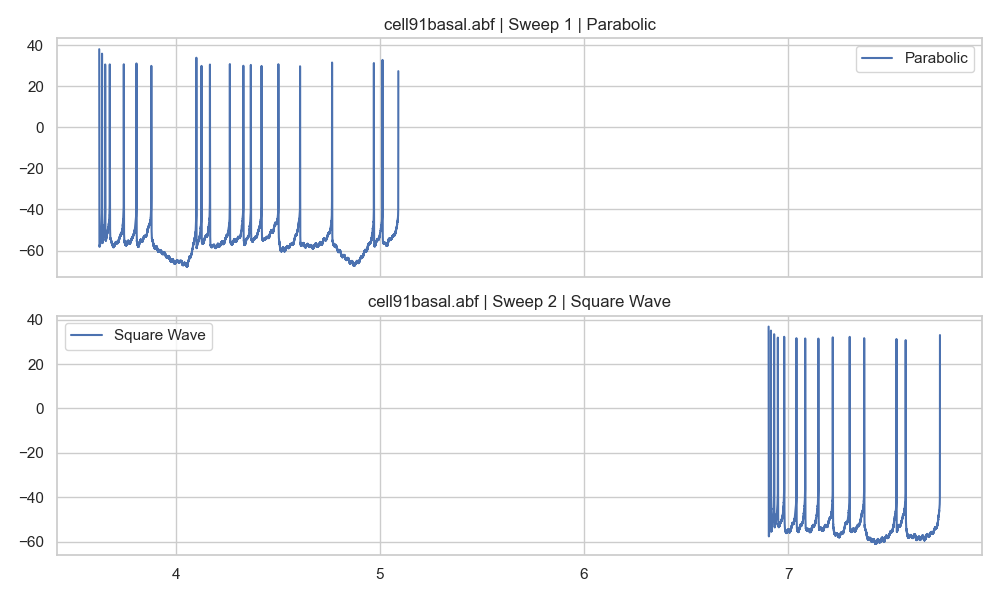

C:\Users\manur\AppData\Local\Temp\ipykernel_15908\3284055771.py:248: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



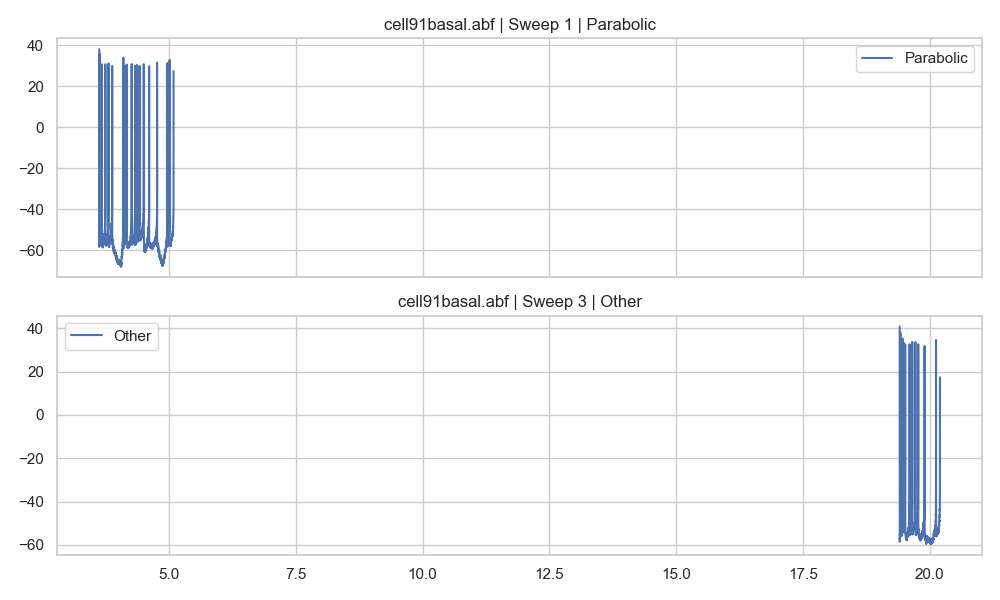

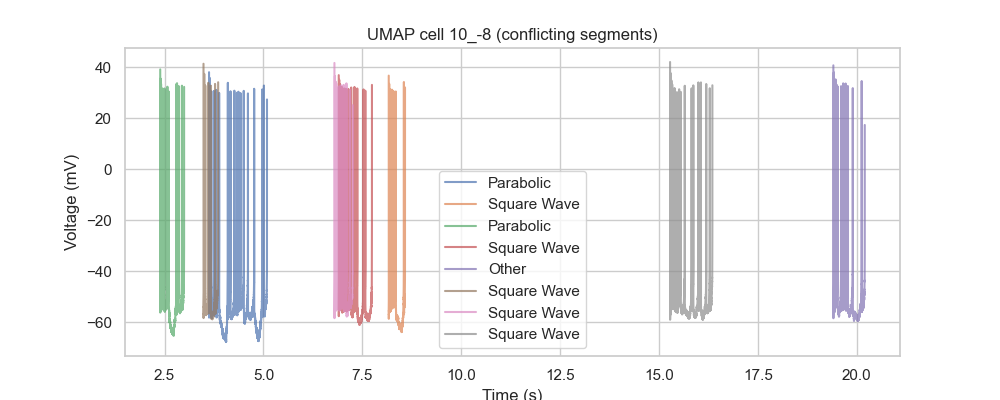

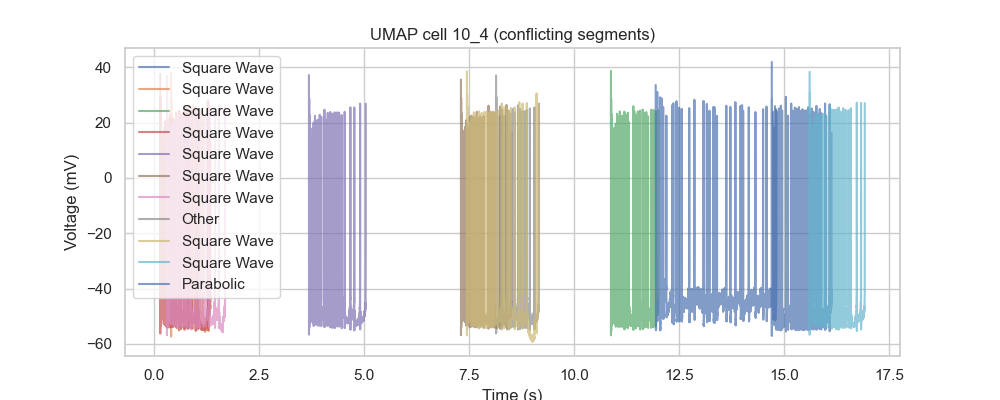

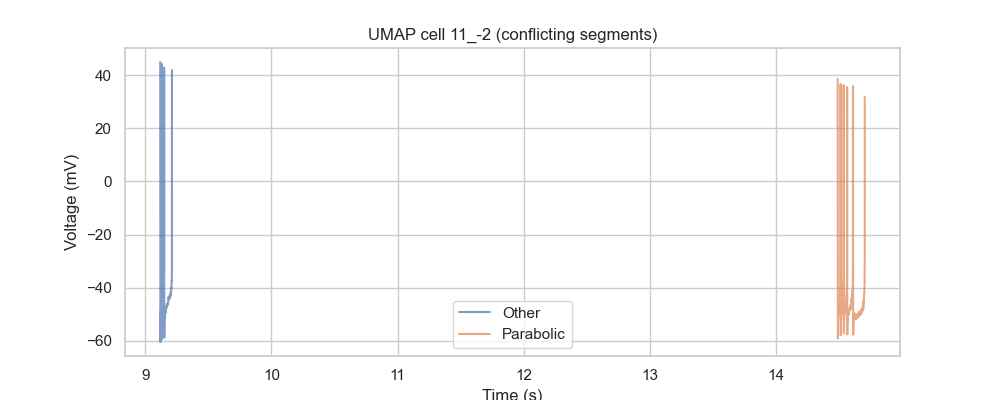

c:\Users\manur\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipympl\backend_nbagg.py:335: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



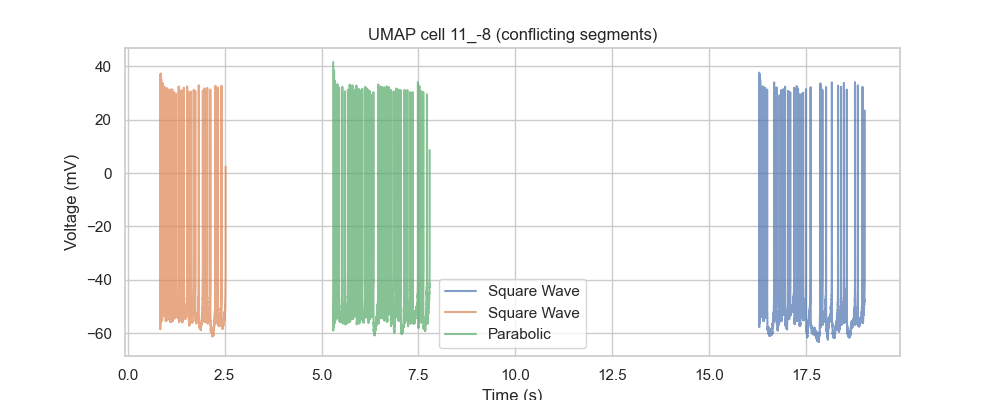

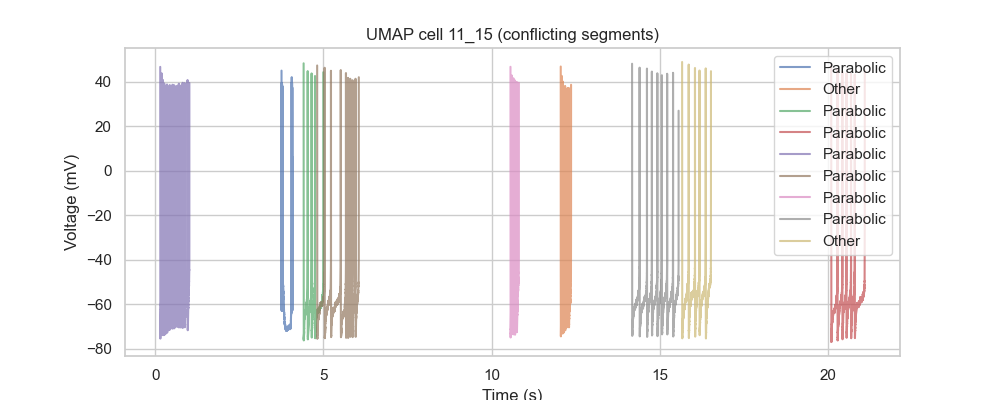

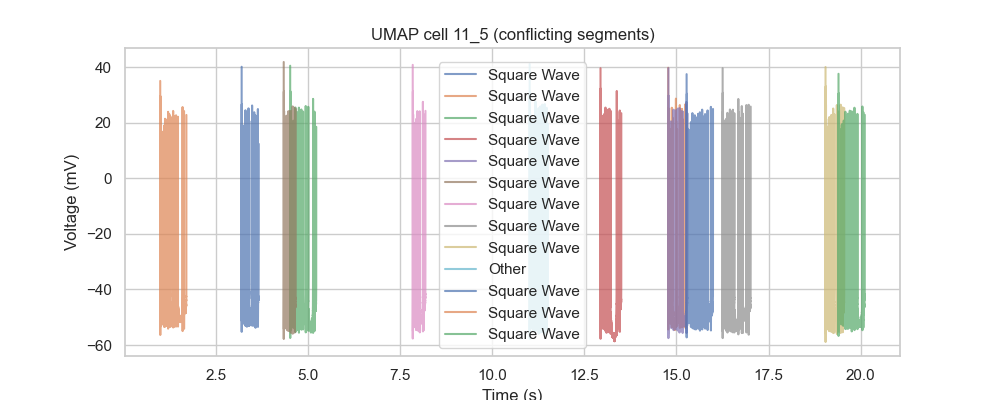

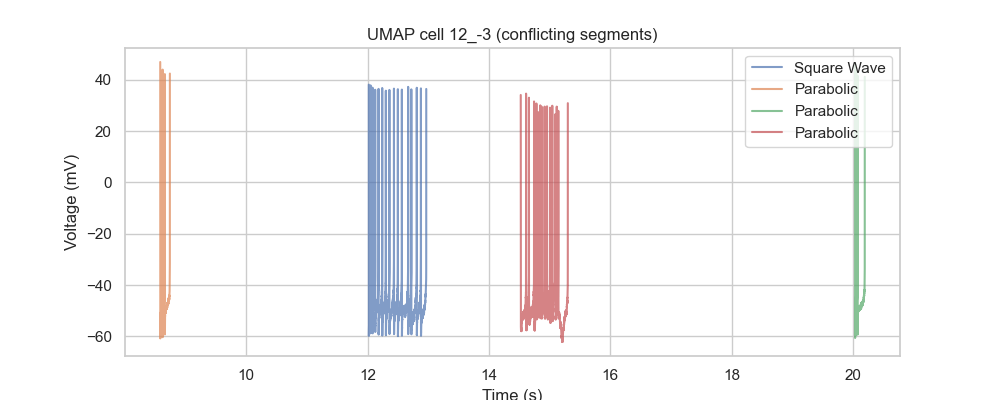

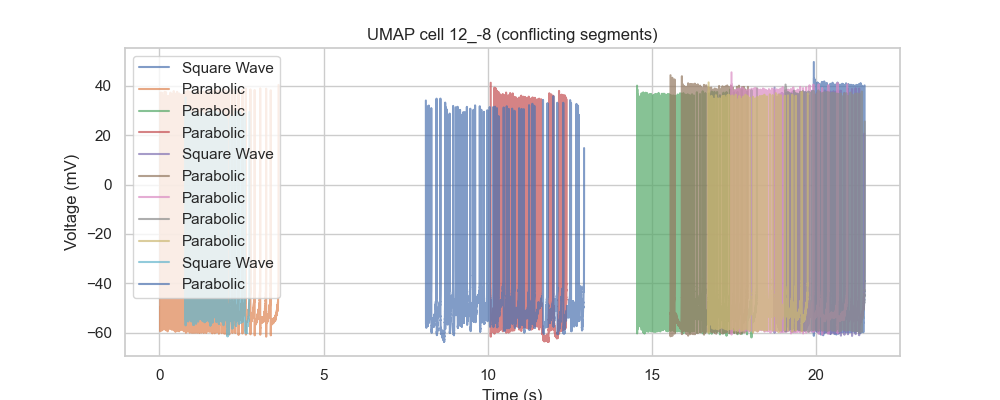

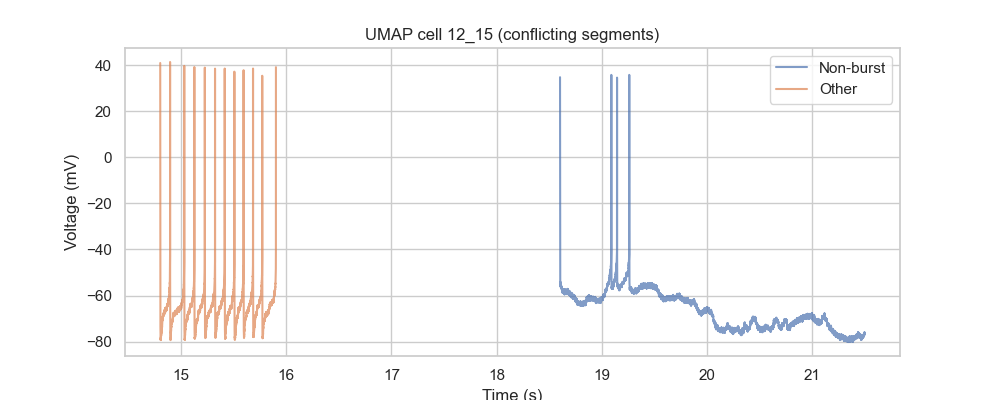

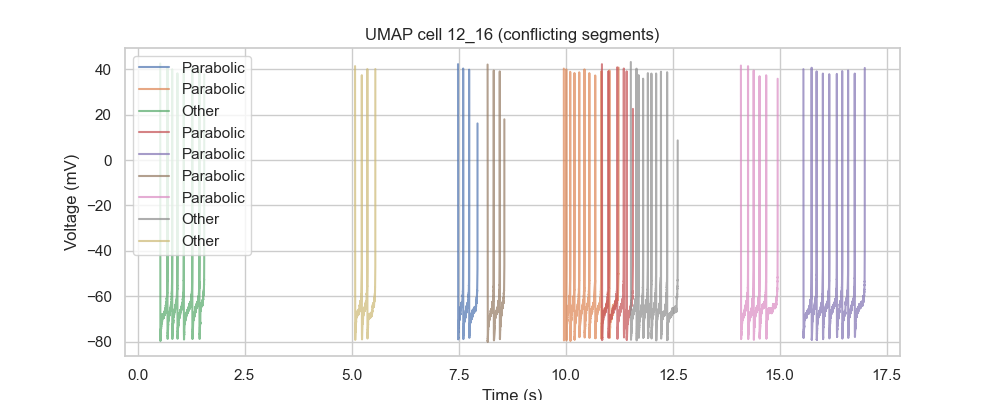

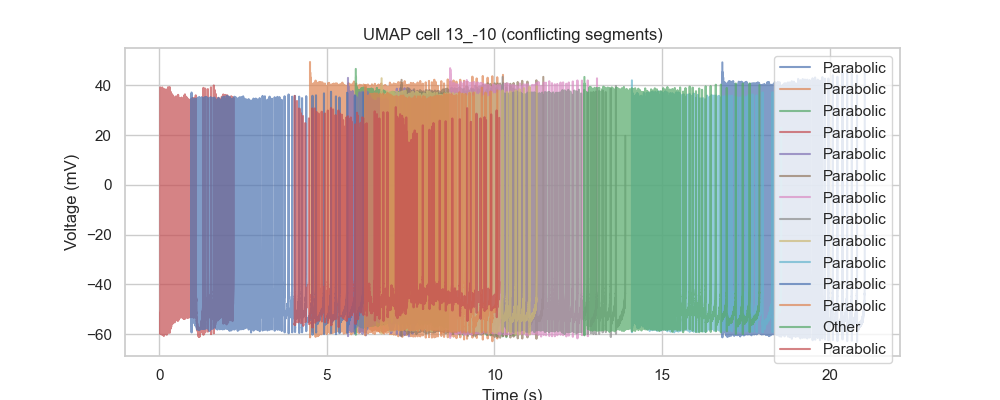

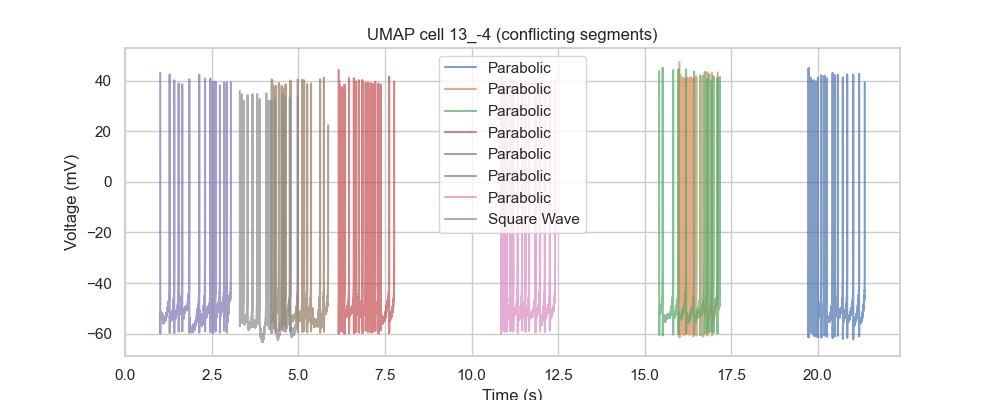

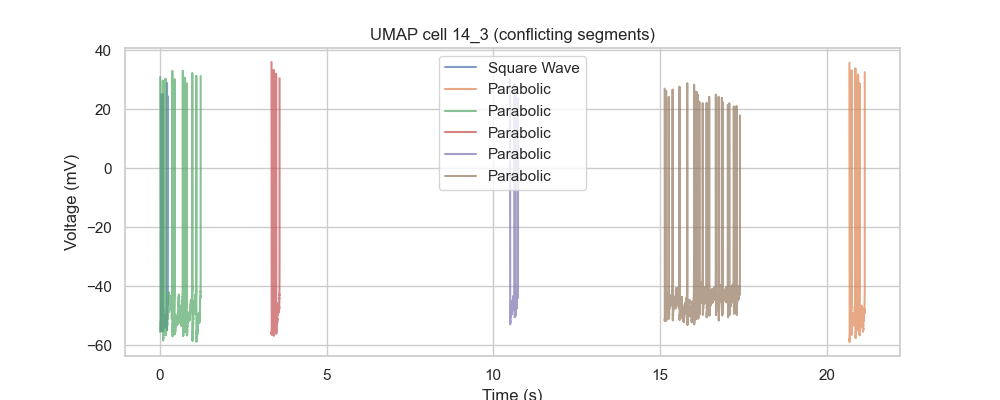

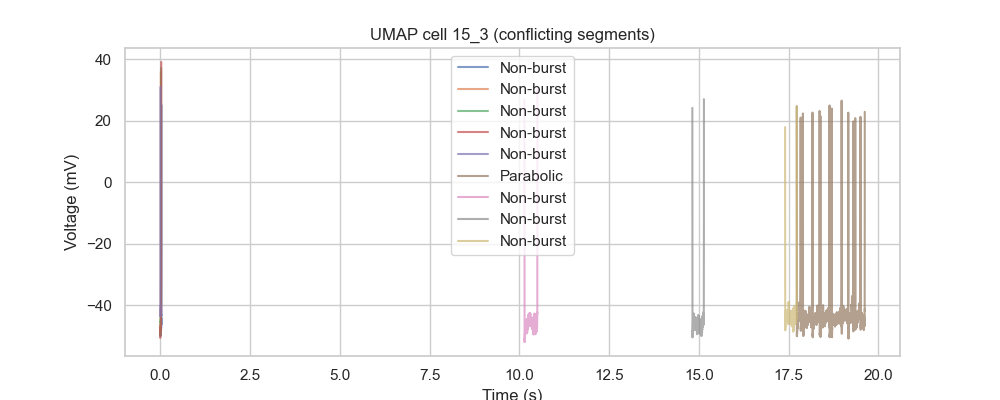

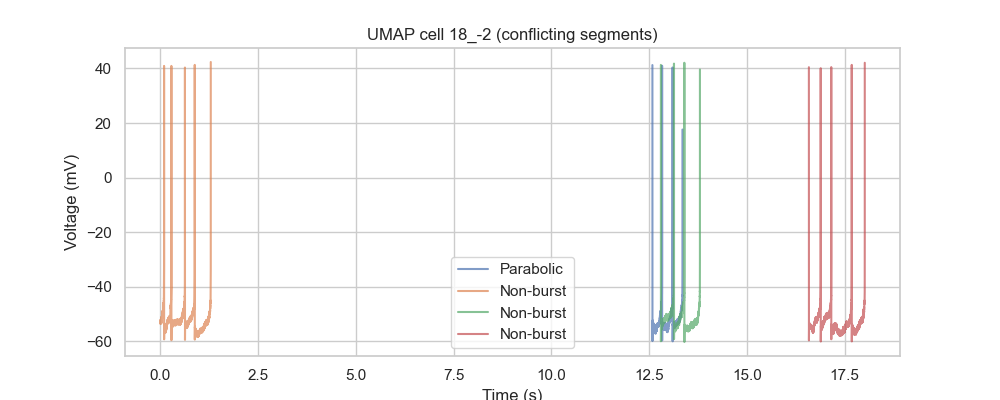

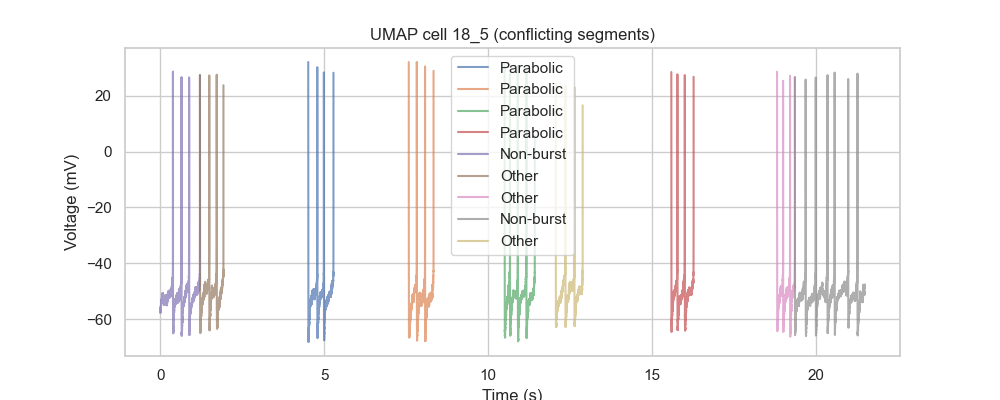

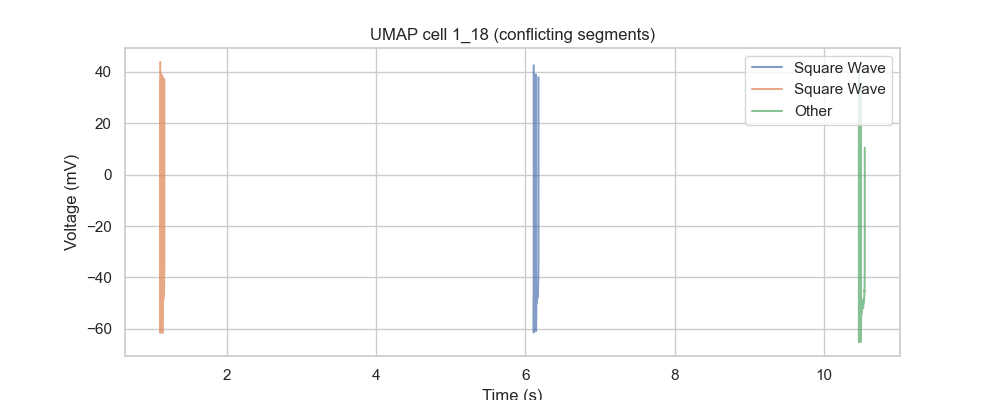

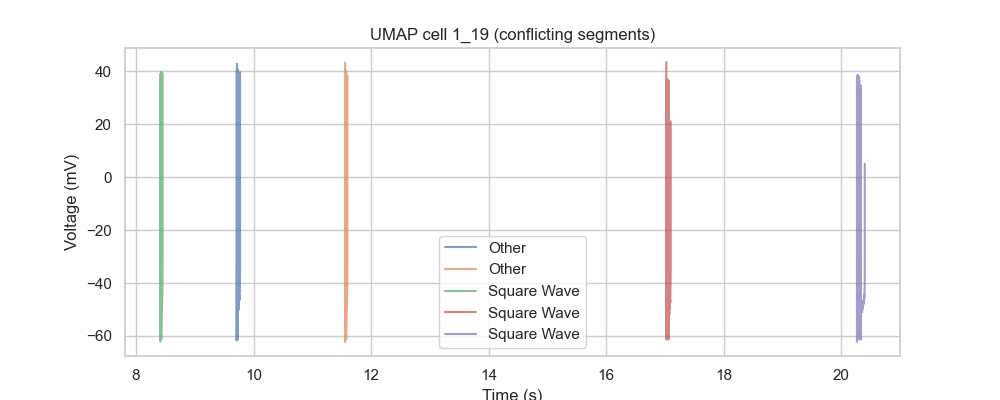

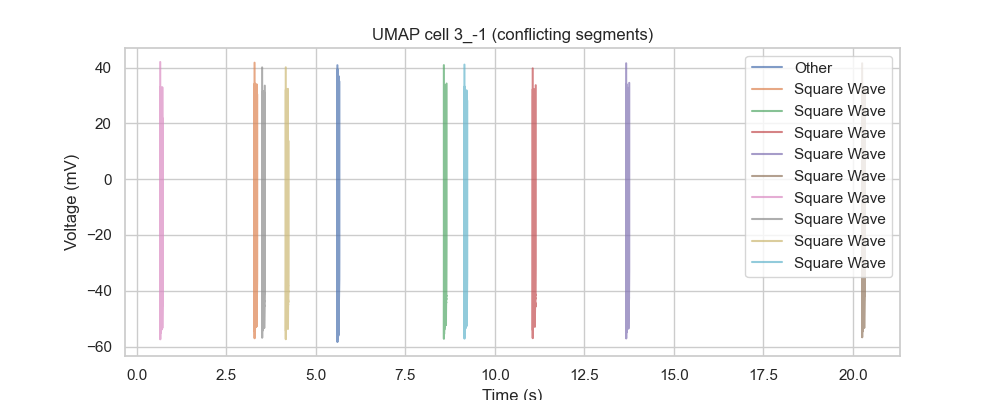

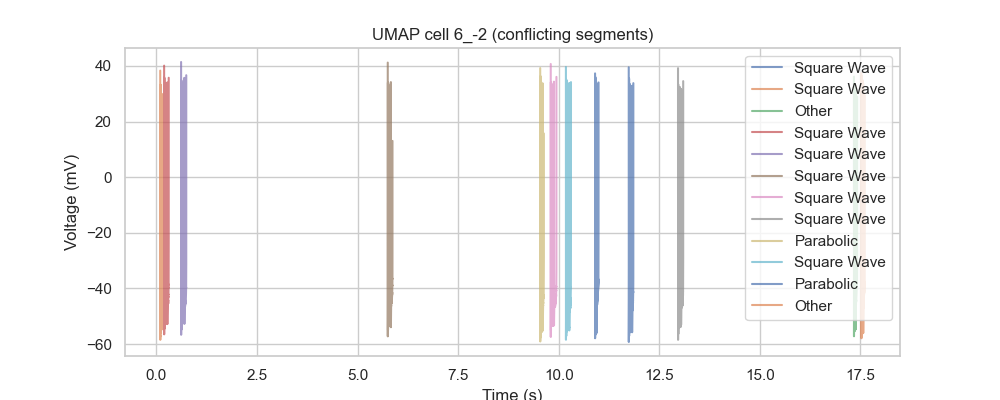

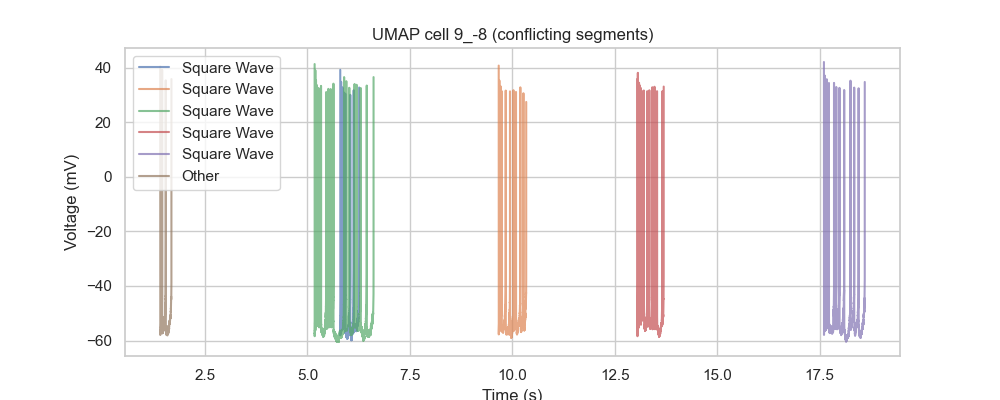

In [ ]:


# 1. Import required libraries
import os                          # File system navigation
import pyabf                       # To read ABF electrophysiology data
import numpy as np                 # Numerical computing
import pandas as pd                # DataFrame for structured storage
from scipy.stats import skew, kurtosis   # Statistical shape descriptors
from scipy.signal import find_peaks       # Peak (spike) detection
from sklearn.preprocessing import StandardScaler  # Feature normalization
import umap                        # Dimensionality reduction (nonlinear manifold learning)
import matplotlib.pyplot as plt     # Plotting library


# 2. Configuration parameters
folder_path = "bursting"       # Folder containing ABF files to analyze
threshold = -35                # Voltage threshold for spike detection (mV)
burst_threshold = 0.3          # Max ISI (interspike interval) to group spikes into a burst (s)
fs = 10000                     # Sampling frequency (Hz)
dt = 1 / fs                    # Time step between samples (s)
min_spikes_in_burst = 4        # Minimum number of spikes to define a burst
bin_size = 0.5                 # UMAP grid size for conflict clustering
N = 3                          # Number of conflict pairs to visualize

# This list will accumulate metrics for every detected segment (burst or non-burst)
all_segment_metrics = []

# 3. Burst detection and feature extraction

# Get all ABF files in the folder
abf_files = [f for f in os.listdir(folder_path) if f.endswith(".abf")]

for file_name in abf_files:
    file_path = os.path.join(folder_path, file_name)
    abf = pyabf.ABF(file_path)  # Load the ABF file into memory

    # Iterate through each sweep in the ABF recording
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        time = abf.sweepX       # Time vector (seconds)
        voltage = abf.sweepY    # Voltage trace (mV)

        # Spike detection
        # Using a simple amplitude threshold to locate peaks above threshold
        peaks, _ = find_peaks(voltage, height=threshold)
        spike_times = peaks / fs  # Convert spike indices to seconds

        # Burst detection based on interspike interval (ISI)
        bursts = []
        if len(spike_times) >= min_spikes_in_burst:
            isi = np.diff(spike_times)  # Compute interspike intervals
            current_burst = [spike_times[0]]

            # Iterate through each ISI to segment bursts
            for i in range(1, len(spike_times)):
                if isi[i - 1] < burst_threshold:
                    # Still part of the same burst
                    current_burst.append(spike_times[i])
                else:
                    # ISI exceeded threshold: burst ends
                    if len(current_burst) >= min_spikes_in_burst:
                        bursts.append((current_burst[0], current_burst[-1]))
                    current_burst = [spike_times[i]]

            # If the final burst is valid, append it too
            if len(current_burst) >= min_spikes_in_burst:
                bursts.append((current_burst[0], current_burst[-1]))

        # Segment the sweep into bursts and non-bursts
        segments = []
        for start, end in bursts:
            segments.append((start, end, "Burst"))

        if bursts:
            # Add non-burst intervals between and around bursts
            if bursts[0][0] > time[0]:
                segments.insert(0, (time[0], bursts[0][0], "Non-burst"))
            for i in range(len(bursts) - 1):
                segments.append((bursts[i][1], bursts[i + 1][0], "Non-burst"))
            if bursts[-1][1] < time[-1]:
                segments.append((bursts[-1][1], time[-1], "Non-burst"))
        else:
            # If no bursts are found, the entire sweep is "Non-burst"
            segments.append((time[0], time[-1], "Non-burst"))

        # Burst classification:
        burst_types = []
        for i, (seg_start, seg_end, seg_type) in enumerate(segments):
            if seg_type == "Burst":
                seg_mask = (time >= seg_start) & (time <= seg_end)
                seg_voltage = voltage[seg_mask]

                # Compute baseline before and after the burst
                prev_mean = np.nan
                next_mean = np.nan
                if i > 0:
                    prev_end = segments[i - 1][1]
                    inter_mask_prev = (time > prev_end) & (time < seg_start)
                    if np.any(inter_mask_prev):
                        prev_mean = np.mean(voltage[inter_mask_prev])
                if i < len(segments) - 1:
                    next_start = segments[i + 1][0]
                    inter_mask_next = (time > seg_end) & (time < next_start)
                    if np.any(inter_mask_next):
                        next_mean = np.mean(voltage[inter_mask_next])

                inter_mean = np.nanmean([prev_mean, next_mean])
                burst_min = np.min(seg_voltage)

                # Classification logic:
                if np.isnan(inter_mean):
                    burst_type = "Other"
                elif burst_min > inter_mean:
                    burst_type = "Square Wave"
                elif burst_min < inter_mean:
                    burst_type = "Parabolic"
                else:
                    burst_type = "Other"
            else:
                burst_type = "Non-burst"

            burst_types.append(burst_type)

        # Compute metrics for each segment
        for j, (seg_start, seg_end, seg_type) in enumerate(segments):
            seg_mask = (time >= seg_start) & (time <= seg_end)
            seg_voltage = voltage[seg_mask]
            duration = seg_end - seg_start
            burst_type = burst_types[j]

            # Spike features within the segment
            seg_peaks, _ = find_peaks(seg_voltage, height=threshold)
            num_peaks = len(seg_peaks)
            mean_isi = np.mean(np.diff(seg_peaks / fs)) if num_peaks >= 2 else 0

            if len(seg_voltage) < 2:
                # Avoid numerical issues with too-short segments
                mean_val = std_val = min_val = max_val = skew_val = kurt_val = area_val = 0
                mean_d = std_d = min_d = max_d = skew_d = kurt_d = 0
            else:
                # Basic statistical metrics
                mean_val = np.mean(seg_voltage)
                std_val = np.std(seg_voltage)
                min_val = np.min(seg_voltage)
                max_val = np.max(seg_voltage)
                skew_val = skew(seg_voltage)
                kurt_val = kurtosis(seg_voltage)
                area_val = np.trapezoid(seg_voltage, dx=dt)  # Integral (approx area)

                # Derivative (first-order dynamics)
                deriv = np.diff(seg_voltage) / dt
                mean_d = np.mean(deriv)
                std_d = np.std(deriv)
                min_d = np.min(deriv)
                max_d = np.max(deriv)
                skew_d = skew(deriv)
                kurt_d = kurtosis(deriv)

            # Append all computed metrics to global list
            all_segment_metrics.append([
                file_name, sweep, seg_type, burst_type, seg_start, seg_end, duration,
                num_peaks, mean_isi,
                mean_val, std_val, min_val, max_val, skew_val, kurt_val, area_val,
                mean_d, std_d, min_d, max_d, skew_d, kurt_d
            ])

# 4. Build DataFrame and run UMAP dimensionality reduction
df_segments = pd.DataFrame(all_segment_metrics, columns=[
    "File_Name", "Sweep", "Segment_Type", "Burst_Type",
    "Segment_Start", "Segment_End", "Duration",
    "Num_Peaks", "Mean_ISI", "Mean", "Std", "Min", "Max",
    "Skewness", "Kurtosis", "Area",
    "Mean_Deriv", "Std_Deriv", "Min_Deriv", "Max_Deriv",
    "Skewness_Deriv", "Kurtosis_Deriv"
])

# Select quantitative metrics for embedding
header = [
    "Duration", "Num_Peaks", "Mean_ISI",
    "Mean", "Std", "Min", "Max",
    "Skewness", "Kurtosis", "Area",
    "Mean_Deriv", "Std_Deriv", "Min_Deriv", "Max_Deriv",
    "Skewness_Deriv", "Kurtosis_Deriv"
]

# Standardize metrics before UMAP (critical for balanced scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_segments[header])

# Apply UMAP: nonlinear dimensionality reduction preserving local topology
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)
df_segments["UMAP1"] = embedding[:, 0]
df_segments["UMAP2"] = embedding[:, 1]

# Save the results to CSV for further analysis
df_segments.to_csv("segment_voltage_metrics_with_ISI_and_peaks.csv", index=False)
print(f"CSV saved with {len(df_segments)} segments and UMAP coordinates.")

# 5. Identify conflict regions in UMAP space
# Define discrete UMAP bins (coarse-grained cells)
df_segments["UMAP_bin"] = (
    (df_segments["UMAP1"] // bin_size).astype(int).astype(str) + "_" +
    (df_segments["UMAP2"] // bin_size).astype(int).astype(str)
)

# Find UMAP bins that contain more than one burst type (i.e., conflicting)
conflict_bins = df_segments.groupby("UMAP_bin")["Burst_Type"].nunique()
conflict_bins = conflict_bins.loc[lambda x: x > 1].index
conflict_data = df_segments[df_segments["UMAP_bin"].isin(conflict_bins)]
print(f"{len(conflict_data)} segments are in conflict regions.")

# 6. Plot pairwise conflicts for visual inspection
pairs = []
for cell, group in conflict_data.groupby("UMAP_bin"):
    types = group["Burst_Type"].unique()
    if len(types) > 1:
        for i, row1 in group.iterrows():
            for j, row2 in group.iterrows():
                if i < j and row1["Burst_Type"] != row2["Burst_Type"]:
                    pairs.append((row1, row2))

print(f"{len(pairs)} conflict pairs detected.")

# Visualize the first N conflicting pairs
for k, (row1, row2) in enumerate(pairs[:N]):
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for ax, row in zip(axs, [row1, row2]):
        file_path = os.path.join(folder_path, row["File_Name"])
        abf = pyabf.ABF(file_path)
        abf.setSweep(int(row["Sweep"]))
        time = abf.sweepX
        voltage = abf.sweepY
        mask = (time >= row["Segment_Start"]) & (time <= row["Segment_End"])
        ax.plot(time[mask], voltage[mask], label=row["Burst_Type"])
        ax.set_title(f"{row['File_Name']} | Sweep {row['Sweep']} | {row['Burst_Type']}")
        ax.legend()
    plt.tight_layout()
    plt.show()

# 7. Overlay all segments within each conflictive UMAP region
for cell, group in conflict_data.groupby("UMAP_bin"):
    if len(group["Burst_Type"].unique()) > 1:
        plt.figure(figsize=(10, 4))
        for _, row in group.iterrows():
            file_path = os.path.join(folder_path, row["File_Name"])
            abf = pyabf.ABF(file_path)
            abf.setSweep(int(row["Sweep"]))
            time = abf.sweepX
            voltage = abf.sweepY
            mask = (time >= row["Segment_Start"]) & (time <= row["Segment_End"])
            plt.plot(time[mask], voltage[mask], label=row["Burst_Type"], alpha=0.7)
        plt.title(f"UMAP cell {cell} (conflicting segments)")
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (mV)")
        plt.legend()
        plt.show()
